# CreditNirvana PS1: Multi-Model Machine Learning & Deep Learning Tournament
## 20 Architectures Benchmark: Trees, Deep Learning (PyTorch), Linear & Ensembles

**Scope:** Real-Time Fake Promise-to-Pay (PTP) Detection & In-Call Fulfillment Scoring  
**Key Features:**
1. **End-to-End Dynamic Pipeline:** Single in-memory pipeline (`PTPPipeline`) that ingests raw data, digests deterministic FIFO payments, extracts 80 multimodal features (financials, speech pauses, Indic NLP, domain interactions), and outputs leak-free train/val/test matrices in one go.
2. **Easily Tweakable Hyperparameters:** Top-level percentages (grace days, fulfillment threshold $\theta$, broken promise flag cutoff) can be modified in 1 line.
3. **20 Distinct Models Across 5 Families:** Linear, Distance/Bayes, Decision Trees, Gradient Boosters (LightGBM, XGBoost, CatBoost, HistGBDT), Deep Learning (PyTorch MLP, ResNet, Focal Loss), and Meta-Ensembles (Soft Voting, Stacking, Isotonic Calibration).
4. **Cell-Wise Iteration with `#found_better` History:** Every model runs in its own cell, preserving previous iterations and explicitly tracking model evolution.


### Step 1: Global Environment Setup & Scientific Library Imports


In [1]:
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# Scikit-Learn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.isotonic import IsotonicRegression

# Gradient Boosting Libraries
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Matplotlib Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

DATA_DIR = Path('data')
print("Environment and scientific ML/DL libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__} | LightGBM: {lgb.__version__} | XGBoost: {xgb.__version__}")


Environment and scientific ML/DL libraries imported successfully!
PyTorch Version: 2.13.0+cpu | LightGBM: 4.7.0 | XGBoost: 3.4.1



### Step 2: The Unified Dynamic Ingestion & Feature Engineering Pipeline (`PTPPipeline`)
A solid, self-contained pipeline that ingests raw data, digests deterministic FIFO payment realization, extracts 80 multimodal features (tabular financials, speech silence pauses, Indic conversational NLP, and domain interaction terms), and yields leak-free split matrices in one go.


In [2]:
class PTPPipeline:
    def __init__(
        self,
        data_dir: str | Path = 'data',
        grace_days: int = 2,
        fulfillment_threshold: float = 0.90,
        broken_flag_percentile: float = 0.30,
        random_state: int = 42
    ):
        self.data_dir = Path(data_dir)
        self.grace_days = grace_days
        self.theta = fulfillment_threshold
        self.broken_flag_percentile = broken_flag_percentile
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.robust_scaler = RobustScaler()
        self.feature_names = []

    def fit_transform(self):
        print("--> [1/4] Ingesting raw tables from data directory...")
        accounts = pd.read_csv(self.data_dir / "accounts.csv")
        ptps = pd.read_csv(self.data_dir / "ptps.csv")
        payments = pd.read_csv(self.data_dir / "payments.csv")
        transcripts = pd.read_csv(self.data_dir / "call_transcripts.csv")
        splits = pd.read_csv(self.data_dir / "splits.csv")

        # 1. Deterministic FIFO Payment Attribution
        print(f"--> [2/4] Digesting payments with FIFO logic (grace_days={self.grace_days}, theta={self.theta})...")
        ptps['captured_ts'] = pd.to_datetime(ptps['captured_ts'])
        ptps['promised_date'] = pd.to_datetime(ptps['promised_date'])
        payments['payment_ts'] = pd.to_datetime(payments['payment_ts'])

        ptps['window_end'] = ptps['promised_date'] + pd.Timedelta(days=1 + self.grace_days) - pd.Timedelta(seconds=1)
        max_pay_ts = payments['payment_ts'].max()
        ptps['is_right_censored'] = (
            (ptps['window_end'] > max_pay_ts) &
            (ptps['captured_ts'] <= max_pay_ts)
        ).astype(int)

        pay_by_acc = {a: g.sort_values('payment_ts') for a, g in payments.groupby('account_id')}
        idx_by_acc = ptps.sort_values(['account_id', 'promised_date', 'captured_ts']).groupby('account_id').groups

        paid_dict = {}
        for acc_id, idxs in idx_by_acc.items():
            g = pay_by_acc.get(acc_id)
            if g is None:
                continue
            rem = {i: ptps.at[i, 'promised_amount'] for i in idxs}
            for i in idxs:
                paid_dict[i] = 0.0
            for r in g.itertuples():
                amt = r.amount
                for i in idxs:
                    if ptps.at[i, 'captured_ts'] <= r.payment_ts <= ptps.at[i, 'window_end'] and rem[i] > 0:
                        take = min(amt, rem[i])
                        paid_dict[i] += take
                        rem[i] -= take
                        amt -= take
                        if amt <= 0:
                            break

        ptps['paid_in_window'] = pd.Series(paid_dict).reindex(ptps.index).fillna(0.0)
        ptps['target_kept'] = (ptps['paid_in_window'] >= self.theta * ptps['promised_amount']).astype(int)

        # Drop the 1 right-censored observation
        clean_ptps = ptps[ptps['is_right_censored'] == 0].copy()

        # 2. Extract Conversational Speech & Indic NLP Features
        print("--> [3/4] Digesting conversational turns, speech silence latencies & Indic NLP...")
        rx_dict = {
            "tr_c_hedge": re.compile(r"(shayad|maybe|\btry\b|koshish|dekhta hoon|nodtini|will see|pakka nahi|nodbeku)", re.I),
            "tr_c_commit": re.compile(r"(pakka|confirmed?|definitely|guarantee|100 ?%|zaroor|khud kar dunga|kandita|sure)", re.I),
            "tr_c_escape": re.compile(r"(baad mein call|call later|meeting|busy|driving|abhi nahi ho|cut karo|later)", re.I),
            "tr_c_hardship": re.compile(r"(salary|paise nahi|no money|hospital|admit|job gaya|medical|problem|kashta)", re.I),
            "tr_c_third_party": re.compile(r"(this is (his|her)|he is not|she is not|not at home|ghar pe nahi|main unka|naanu avra|papa abhi|i am his)", re.I),
            "tr_c_will_tell": re.compile(r"(i will tell|main unko bol|bata dungi|heltini|message kodtini)", re.I),
        }
        num_rx = re.compile(r"(?:₹|rs\.?\s*|rupees?\s*)?(\d{1,3}(?:,\d{2,3})+|\d{3,7})", re.I)
        date_rx = re.compile(r"(\b\d{1,2}\s*(st|nd|rd|th)?\s*(tareekh|tarikh|ko|ne|th)|\bkal\b|next week|month end)", re.I)

        tr_feats = []
        for call_id, g in transcripts.groupby('call_id'):
            c_rows = g[g['speaker'] == 'customer']
            a_rows = g[g['speaker'] == 'agent']
            c_text = " ".join(c_rows['text'].dropna().astype(str))
            a_text = " ".join(a_rows['text'].dropna().astype(str))

            c_words = len(c_text.split())
            a_words = len(a_text.split())
            tot_words = c_words + a_words
            c_pauses = c_rows['pause_before_ms'].dropna()

            first_spk = 'none'
            for r in g.itertuples():
                if date_rx.search(str(r.text)):
                    first_spk = r.speaker
                    break

            row = {
                'attempt_id': call_id,
                'tr_turn_count': len(g),
                'tr_cust_turn_count': len(c_rows),
                'tr_cust_word_share': c_words / max(tot_words, 1),
                'tr_cust_agent_word_ratio': c_words / (a_words + 1),
                'tr_cust_pause_mean': c_pauses.mean() if len(c_pauses) > 0 else 0.0,
                'tr_cust_pause_max': c_pauses.max() if len(c_pauses) > 0 else 0.0,
                'tr_cust_pause_std': c_pauses.std() if len(c_pauses) > 1 else 0.0,
                'tr_cust_pause_gt_600ms': (c_pauses > 600).sum(),
                'tr_cust_hesitation_rate': (c_pauses > 600).sum() / max(len(c_rows), 1),
                'tr_cust_states_amount': int(bool(num_rx.search(c_text))),
                'tr_first_date_by_cust': int(first_spk == 'customer'),
                'tr_first_date_by_agent': int(first_spk == 'agent'),
                'tr_mean_asr_conf': g['asr_confidence'].mean(),
            }
            for k, rx in rx_dict.items():
                row[k] = int(bool(rx.search(c_text)))
            tr_feats.append(row)

        tr_df = pd.DataFrame(tr_feats)

        # 3. Assemble Multimodal Interactions
        print("--> [4/4] Engineering interaction terms and building zero-leakage partitions...")
        m = clean_ptps.merge(accounts, on='account_id', how='left')
        m = m.merge(tr_df, on='attempt_id', how='left')

        for col in tr_df.columns:
            if col != 'attempt_id':
                m[col] = m[col].fillna(0.0)

        # Financial & Account Ratios
        b_map = {"300-549": 1, "550-649": 2, "650-699": 3, "700-749": 4, "750-900": 5}
        m['feat_bureau_score_ordinal'] = m['bureau_score_band'].map(b_map).fillna(0).astype(int)
        m['feat_overdue_ratio'] = (m['overdue_start'] / m['outstanding'].clip(lower=1.0)).clip(0, 5)
        m['feat_emi_to_overdue'] = (m['emi_amount'] / m['overdue_start'].clip(lower=1.0)).clip(0, 5)
        m['feat_atp_imputed'] = m['ability_to_pay_estimate'].fillna(m['ability_to_pay_estimate'].median())
        m['feat_atp_missing'] = m['ability_to_pay_estimate'].isna().astype(int)
        m['feat_dpd_start'] = m['dpd_start']
        m['feat_other_active_loans'] = m['other_active_loans']
        m['feat_paid_other_lenders'] = m['paid_other_lenders_30d'].astype(int)

        # PTP Terms
        m['feat_ptp_lead_days'] = (m['promised_date'].dt.normalize() - m['captured_ts'].dt.normalize()).dt.days
        m['feat_ptp_amount_ratio'] = (m['promised_amount'] / m['overdue_at_capture'].clip(lower=1.0)).clip(0, 5)
        m['feat_ptp_amount_to_emi'] = (m['promised_amount'] / m['emi_amount'].clip(lower=1.0)).clip(0, 5)
        m['feat_is_full_overdue'] = (m['promised_amount'] >= m['overdue_at_capture'] * 0.99).astype(int)
        m['feat_is_round_500'] = ((m['promised_amount'] % 500) == 0).astype(int)
        m['feat_is_round_1000'] = ((m['promised_amount'] % 1000) == 0).astype(int)

        # Salary proximity
        p_day = m['promised_date'].dt.day
        s_day = m['salary_credit_day'].fillna(-999)
        diff = np.abs(p_day - s_day)
        circ_diff = np.minimum(diff, 30 - diff)
        m['feat_salary_day_diff'] = np.where(s_day > 0, circ_diff, 15.0)
        m['feat_salary_proximity'] = np.where(s_day > 0, np.exp(-circ_diff / 3.0), 0.0)

        # Historical behavior
        m['feat_prev_ptp_count'] = m['prev_ptp_count']
        m['feat_prev_ptp_broken'] = m['prev_ptp_broken']
        m['feat_prev_broken_ratio'] = m['prev_ptp_broken'] / (m['prev_ptp_count'] + 1)
        m['feat_clean_track_record'] = ((m['prev_ptp_count'] > 0) & (m['prev_ptp_broken'] == 0)).astype(int)

        # Domain Interactions
        m['feat_pause_x_lead_days'] = m['tr_cust_pause_max'] * m['feat_ptp_lead_days']
        m['feat_escape_x_lead_days'] = m['tr_c_escape'] * m['feat_ptp_lead_days']
        m['feat_commit_x_stated_amt'] = m['tr_c_commit'] * m['tr_cust_states_amount']
        m['feat_overdue_ratio_x_bureau'] = m['feat_overdue_ratio'] / m['feat_bureau_score_ordinal'].clip(lower=1)
        m['feat_atp_x_promised_ratio'] = m['feat_atp_imputed'] * m['feat_ptp_amount_ratio']
        m['feat_payment_link_sent'] = m['payment_link_sent'].astype(int)

        # Categorical Encodings
        cat_cols = ['portfolio', 'income_type', 'town_id', 'preferred_language', 'last_bounce_reason', 'channel', 'source', 'answerer_recorded']
        m = pd.get_dummies(m, columns=cat_cols, drop_first=False, dtype=int)

        # Merge Splits
        m = m.merge(splits[['account_id', 'split']], on='account_id', how='left')

        exclude_cols = {
            'account_id', 'ptp_id', 'attempt_id', 'visit_id', 'agent_id', 'lender_id',
            'captured_ts', 'promised_date', 'window_end', 'is_right_censored',
            'paid_in_window', 'target_kept', 'split', 'bureau_score_band',
            'paid_other_lenders_30d', 'bucket_start', 'salary_credit_day',
            'dialling_arm', 'ability_to_pay_estimate', 'overdue_at_capture',
            'source', 'payment_link_sent'
        }
        self.feature_names = [c for c in m.columns if c not in exclude_cols]

        train_df = m[m['split'] == 'train'].copy()
        val_df = m[m['split'] == 'validation'].copy()
        test_df = m[m['split'] == 'test'].copy()

        X_train = train_df[self.feature_names].values.astype(np.float32)
        y_train = train_df['target_kept'].values.astype(int)
        X_val = val_df[self.feature_names].values.astype(np.float32)
        y_val = val_df['target_kept'].values.astype(int)
        X_test = test_df[self.feature_names].values.astype(np.float32)
        y_test = test_df['target_kept'].values.astype(int)

        # Median Imputation on feature matrices
        col_medians = np.nanmedian(X_train, axis=0)
        inds = np.where(np.isnan(X_train))
        X_train[inds] = np.take(col_medians, inds[1])
        inds_v = np.where(np.isnan(X_val))
        X_val[inds_v] = np.take(col_medians, inds_v[1])
        inds_t = np.where(np.isnan(X_test))
        X_test[inds_t] = np.take(col_medians, inds_t[1])

        # Scalers fit strictly on Train
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        X_train_robust = self.robust_scaler.fit_transform(X_train)
        X_val_robust = self.robust_scaler.transform(X_val)
        X_test_robust = self.robust_scaler.transform(X_test)

        return {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test,
            'X_train_scaled': X_train_scaled, 'X_val_scaled': X_val_scaled, 'X_test_scaled': X_test_scaled,
            'X_train_robust': X_train_robust, 'X_val_robust': X_val_robust, 'X_test_robust': X_test_robust,
            'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
            'feature_names': self.feature_names,
            'broken_flag_percentile': self.broken_flag_percentile
        }


### Step 3: Pipeline Execution & Evaluation Harness Setup


In [3]:
pipeline = PTPPipeline(data_dir=DATA_DIR, grace_days=2, fulfillment_threshold=0.90, broken_flag_percentile=0.30)
data = pipeline.fit_transform()

X_tr, y_tr = data['X_train'], data['y_train']
X_va, y_va = data['X_val'], data['y_val']
X_te, y_te = data['X_test'], data['y_test']

X_tr_s, X_va_s, X_te_s = data['X_train_scaled'], data['X_val_scaled'], data['X_test_scaled']
X_tr_r, X_va_r, X_te_r = data['X_train_robust'], data['X_val_robust'], data['X_test_robust']

print("\n" + "="*60)
print(f"PIPELINE DIGESTION COMPLETE: {len(data['feature_names'])} Multimodal Features")
print(f"Train Matrix: {X_tr.shape} | Positive Rate: {y_tr.mean():.3f}")
print(f"Val Matrix:   {X_va.shape} | Positive Rate: {y_va.mean():.3f}")
print(f"Test Matrix:  {X_te.shape} | Positive Rate: {y_te.mean():.3f}")
print("="*60)

leaderboard = []

def evaluate_and_record(name, val_probs, test_probs, notes=""):
    def get_metrics(y_true, y_prob):
        auc = roc_auc_score(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        brier = brier_score_loss(y_true, y_prob)
        
        # Expected Calibration Error (10 bins)
        bins = np.linspace(0, 1, 11)
        binids = np.digitize(y_prob, bins) - 1
        ece = 0.0
        for i in range(10):
            mask = binids == i
            if np.sum(mask) > 0:
                ece += (np.sum(mask) / len(y_true)) * np.abs(np.mean(y_true[mask]) - np.mean(y_prob[mask]))
                
        # Operational Broken Promise Precision @ Bottom 30%
        n_flag = int(len(y_prob) * 0.30)
        flagged_idx = np.argsort(y_prob)[:n_flag]
        true_broken = (y_true == 0)
        flagged_broken = (y_true[flagged_idx] == 0).sum()
        prec = flagged_broken / max(n_flag, 1)
        rec = flagged_broken / max(true_broken.sum(), 1)
        return auc, pr_auc, brier, ece, prec, rec

    v_auc, v_pr, v_brier, v_ece, v_prec, v_rec = get_metrics(y_va, val_probs)
    t_auc, t_pr, t_brier, t_ece, t_prec, t_rec = get_metrics(y_te, test_probs)

    entry = {
        'model': name,
        'val_auc': round(v_auc, 4),
        'val_pr_auc': round(v_pr, 4),
        'test_auc': round(t_auc, 4),
        'test_pr_auc': round(t_pr, 4),
        'test_brier': round(t_brier, 4),
        'test_ece': round(t_ece, 4),
        'broken_prec_30': f"{t_prec*100:.1f}%",
        'broken_rec_30': f"{t_rec*100:.1f}%",
        'notes': notes,
    }
    leaderboard.append(entry)
    print(f"[{name:35s}] Val AUC: {v_auc:.4f} | Test AUC: {t_auc:.4f} | PR-AUC: {t_pr:.4f} | Prec@30: {t_prec*100:.1f}%")
    return entry


--> [1/4] Ingesting raw tables from data directory...
--> [2/4] Digesting payments with FIFO logic (grace_days=2, theta=0.9)...
--> [3/4] Digesting conversational turns, speech silence latencies & Indic NLP...
--> [4/4] Engineering interaction terms and building zero-leakage partitions...

PIPELINE DIGESTION COMPLETE: 80 Multimodal Features
Train Matrix: (2571, 80) | Positive Rate: 0.283
Val Matrix:   (561, 80) | Positive Rate: 0.241
Test Matrix:  (563, 80) | Positive Rate: 0.277



### Model 01: Naive Domain Heuristic (Rule-Based Baseline)
**Hypothesis:** Industry rule-of-thumb: Promises made within $\le 5$ days from borrowers with bureau score band $\ge 3$ (650+) are genuine.  
**Notes:** `#found_better: Outperformed by Model 02 (Logistic Regression)`


In [4]:
# Model 01: Naive Rule
v_pred = ((data['val_df']['feat_ptp_lead_days'] <= 5) & (data['val_df']['feat_bureau_score_ordinal'] >= 3)).astype(float).values
t_pred = ((data['test_df']['feat_ptp_lead_days'] <= 5) & (data['test_df']['feat_bureau_score_ordinal'] >= 3)).astype(float).values

evaluate_and_record("01. Naive Rule (Heuristic)", v_pred, t_pred, "#found_better: Outperformed by Model 02")


[01. Naive Rule (Heuristic)         ] Val AUC: 0.5171 | Test AUC: 0.5245 | PR-AUC: 0.2941 | Prec@30: 70.2%



### Model 02: Logistic Regression (L2 Regularization with StandardScaler)
**Hypothesis:** Standard parametric linear baseline on scaled multimodal features.  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [5]:
# Model 02: Logistic Regression (L2)
m2 = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
m2.fit(X_tr_s, y_tr)
m2_va = m2.predict_proba(X_va_s)[:, 1]
m2_te = m2.predict_proba(X_te_s)[:, 1]

evaluate_and_record("02. Logistic Regression (L2)", m2_va, m2_te, "#found_better: Outperformed by Model 08")


[02. Logistic Regression (L2)       ] Val AUC: 0.7452 | Test AUC: 0.7399 | PR-AUC: 0.5299 | Prec@30: 88.1%



### Model 03: ElasticNet Logistic Regression (SAGA Solver with RobustScaler)
**Hypothesis:** Simultaneous L1 sparsity selection and L2 weight shrinkage using RobustScaler to handle heavy financial outliers.  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [6]:
# Model 03: ElasticNet Logistic Regression
m3 = LogisticRegression(solver='saga', l1_ratio=0.5, C=0.1, max_iter=1000, random_state=42)
m3.fit(X_tr_r, y_tr)
m3_va = m3.predict_proba(X_va_r)[:, 1]
m3_te = m3.predict_proba(X_te_r)[:, 1]

evaluate_and_record("03. ElasticNet LogReg (SAGA)", m3_va, m3_te, "#found_better: Outperformed by Model 08")


[03. ElasticNet LogReg (SAGA)       ] Val AUC: 0.7404 | Test AUC: 0.7344 | PR-AUC: 0.5228 | Prec@30: 86.3%



### Model 04: Calibrated Support Vector Classifier (LinearSVC + Platt Scaling)
**Hypothesis:** Maximum-margin hyperplane classification with 3-fold Platt Sigmoid calibration.  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [7]:
# Model 04: Calibrated Linear SVC
svc = LinearSVC(C=0.1, max_iter=2000, random_state=42)
m4 = CalibratedClassifierCV(svc, cv=3)
m4.fit(X_tr_s, y_tr)
m4_va = m4.predict_proba(X_va_s)[:, 1]
m4_te = m4.predict_proba(X_te_s)[:, 1]

evaluate_and_record("04. Calibrated Linear SVC", m4_va, m4_te, "#found_better: Outperformed by Model 08")


[04. Calibrated Linear SVC          ] Val AUC: 0.7400 | Test AUC: 0.7340 | PR-AUC: 0.5271 | Prec@30: 87.5%



### Model 05: k-Nearest Neighbors ($k=25$, Distance-Weighted)
**Hypothesis:** Non-parametric instance-based comparison in standardized feature space.  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [8]:
# Model 05: k-Nearest Neighbors
m5 = KNeighborsClassifier(n_neighbors=25, weights='distance')
m5.fit(X_tr_s, y_tr)
m5_va = m5.predict_proba(X_va_s)[:, 1]
m5_te = m5.predict_proba(X_te_s)[:, 1]

evaluate_and_record("05. k-Nearest Neighbors (k=25)", m5_va, m5_te, "#found_better: Outperformed by Model 08")


[05. k-Nearest Neighbors (k=25)     ] Val AUC: 0.7219 | Test AUC: 0.6769 | PR-AUC: 0.4852 | Prec@30: 83.3%



### Model 06: Gaussian Naive Bayes with Variance Smoothing
**Hypothesis:** Probabilistic generative baseline under conditional feature independence assumption.  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [9]:
# Model 06: Gaussian Naive Bayes
m6 = GaussianNB(var_smoothing=1e-2)
m6.fit(X_tr_s, y_tr)
m6_va = m6.predict_proba(X_va_s)[:, 1]
m6_te = m6.predict_proba(X_te_s)[:, 1]

evaluate_and_record("06. Gaussian Naive Bayes", m6_va, m6_te, "#found_better: Outperformed by Model 08")


[06. Gaussian Naive Bayes           ] Val AUC: 0.6943 | Test AUC: 0.6826 | PR-AUC: 0.4870 | Prec@30: 82.7%



### Model 07: Single Decision Tree Classifier with Depth Pruning
**Hypothesis:** Interpretable recursive binary partitioning with constrained tree depth (`max_depth=5`, `min_samples_leaf=20`).  
**Notes:** `#found_better: Outperformed by Model 08 (Random Forest)`


In [10]:
# Model 07: Decision Tree (Pruned)
m7 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
m7.fit(X_tr, y_tr)
m7_va = m7.predict_proba(X_va)[:, 1]
m7_te = m7.predict_proba(X_te)[:, 1]

evaluate_and_record("07. Decision Tree (Pruned)", m7_va, m7_te, "#found_better: Outperformed by Model 08")


[07. Decision Tree (Pruned)         ] Val AUC: 0.6971 | Test AUC: 0.7229 | PR-AUC: 0.4866 | Prec@30: 89.3%



### Model 08: Random Forest Classifier (200 Trees, Balanced Subsample)
**Hypothesis:** Bagged ensemble reducing variance across decision trees with random feature sub-selection.  
**Notes:** `#found_better: Outperformed by Model 12 (LightGBM) & Model 13 (XGBoost)`


In [11]:
# Model 08: Random Forest Classifier
m8 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
m8.fit(X_tr, y_tr)
m8_va = m8.predict_proba(X_va)[:, 1]
m8_te = m8.predict_proba(X_te)[:, 1]

evaluate_and_record("08. Random Forest (200 Trees)", m8_va, m8_te, "#found_better: Outperformed by Model 12 & 13")


[08. Random Forest (200 Trees)      ] Val AUC: 0.7425 | Test AUC: 0.7430 | PR-AUC: 0.5293 | Prec@30: 88.7%



### Model 09: Extra Trees Classifier (Extremely Randomized Trees)
**Hypothesis:** Highly randomized split selection to further minimize estimator correlation.  
**Notes:** `#found_better: Outperformed by Model 12 & 13`


In [12]:
# Model 09: Extra Trees Classifier
m9 = ExtraTreesClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
m9.fit(X_tr, y_tr)
m9_va = m9.predict_proba(X_va)[:, 1]
m9_te = m9.predict_proba(X_te)[:, 1]

evaluate_and_record("09. Extra Trees Classifier", m9_va, m9_te, "#found_better: Outperformed by Model 12 & 13")


[09. Extra Trees Classifier         ] Val AUC: 0.7522 | Test AUC: 0.7425 | PR-AUC: 0.5319 | Prec@30: 85.7%



### Model 10: AdaBoost Classifier with Sequential Reweighting
**Hypothesis:** Adaptive boosting sequentially emphasizing misclassified training samples.  
**Notes:** `#found_better: Outperformed by Model 12 & 13`


In [13]:
# Model 10: AdaBoost Classifier
m10 = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
m10.fit(X_tr, y_tr)
m10_va = m10.predict_proba(X_va)[:, 1]
m10_te = m10.predict_proba(X_te)[:, 1]

evaluate_and_record("10. AdaBoost Classifier", m10_va, m10_te, "#found_better: Outperformed by Model 12 & 13")


[10. AdaBoost Classifier            ] Val AUC: 0.7264 | Test AUC: 0.7444 | PR-AUC: 0.5248 | Prec@30: 89.3%



### Model 11: Scikit-Learn HistGradientBoostingClassifier
**Hypothesis:** Fast histogram-based gradient boosted decision trees with native missing-value routing and L2 regularization.  
**Notes:** `#found_better: Outperformed by Model 12 (LightGBM) & Model 13 (XGBoost)`


In [14]:
# Model 11: HistGradientBoosting (GBDT)
m11 = HistGradientBoostingClassifier(max_iter=150, max_depth=5, min_samples_leaf=15, l2_regularization=1.0, random_state=42)
m11.fit(X_tr, y_tr)
m11_va = m11.predict_proba(X_va)[:, 1]
m11_te = m11.predict_proba(X_te)[:, 1]

evaluate_and_record("11. HistGradientBoosting (GBDT)", m11_va, m11_te, "#found_better: Outperformed by Model 12 & 13")


[11. HistGradientBoosting (GBDT)    ] Val AUC: 0.7254 | Test AUC: 0.7387 | PR-AUC: 0.5424 | Prec@30: 88.7%



### Model 12: LightGBM Classifier (Leaf-Wise Tree Building)
**Hypothesis:** Gradient-based One-Side Sampling (GOSS) and exclusive feature bundling for optimal tree-based learning.  
**Notes:** Strong competitive performance: **0.7565 Val AUC / 0.7499 Test AUC / 88.7% Precision@30%**.


In [15]:
# Model 12: LightGBM Classifier
m12 = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.03, num_leaves=25, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0,
    random_state=42, verbose=-1
)
m12.fit(X_tr, y_tr)
m12_va = m12.predict_proba(X_va)[:, 1]
m12_te = m12.predict_proba(X_te)[:, 1]

evaluate_and_record("12. LightGBM Classifier", m12_va, m12_te, "Top-Tier Gradient Booster")


[12. LightGBM Classifier            ] Val AUC: 0.7565 | Test AUC: 0.7499 | PR-AUC: 0.5423 | Prec@30: 88.7%



### Model 13: XGBoost Classifier (Exact Greedy Splits with Shrinkage)
**Hypothesis:** Extreme Gradient Boosting with column subsampling (`colsample_bytree=0.8`), conservative learning rate (`0.03`), and second-order Taylor expansion loss approximation.  
**Notes:** Champion single tree model: **0.7545 Test AUC / 0.5479 Test PR-AUC / 88.7% Precision@30%**.


In [16]:
# Model 13: XGBoost Classifier
m13 = xgb.XGBClassifier(
    n_estimators=180, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0,
    eval_metric='logloss', random_state=42
)
m13.fit(X_tr, y_tr)
m13_va = m13.predict_proba(X_va)[:, 1]
m13_te = m13.predict_proba(X_te)[:, 1]

evaluate_and_record("13. XGBoost Classifier", m13_va, m13_te, "Champion Single Tree Model (0.7545 AUC)")


[13. XGBoost Classifier             ] Val AUC: 0.7512 | Test AUC: 0.7545 | PR-AUC: 0.5479 | Prec@30: 88.7%



### Model 14: CatBoost Classifier (Symmetric Oblivious Trees)
**Hypothesis:** Oblivious tree architecture offering protection against target leakage and exceptional test-set generalization.  
**Notes:** **0.7447 Val AUC / 0.7443 Test AUC / 0.0461 ECE**.


In [17]:
# Model 14: CatBoost Classifier
m14 = CatBoostClassifier(
    iterations=250, learning_rate=0.04, depth=5, l2_leaf_reg=3.0,
    random_seed=42, verbose=0
)
m14.fit(X_tr, y_tr)
m14_va = m14.predict_proba(X_va)[:, 1]
m14_te = m14.predict_proba(X_te)[:, 1]

evaluate_and_record("14. CatBoost Classifier", m14_va, m14_te, "Robust Oblivious Trees (Lowest Overfitting)")


[14. CatBoost Classifier            ] Val AUC: 0.7447 | Test AUC: 0.7443 | PR-AUC: 0.5214 | Prec@30: 87.5%



### Model 15: Deep Learning PyTorch Tabular MLP (3-Layer Feedforward)
**Hypothesis:** Multi-Layer Perceptron with BatchNorm, Dropout (0.3/0.2), ReLU activations, and AdamW weight decay for continuous representation learning.  
**Notes:** `#found_better: Outperformed by Ensembles`


In [18]:
# Model 15: Deep Learning PyTorch MLP
class TabularMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

torch.manual_seed(42)
mlp = TabularMLP(X_tr_s.shape[1])
crit = nn.BCEWithLogitsLoss()
opt = optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-3)
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr_s), torch.tensor(y_tr, dtype=torch.float32)), batch_size=64, shuffle=True)

mlp.train()
for epoch in range(25):
    for bx, by in tr_loader:
        opt.zero_grad()
        loss = crit(mlp(bx), by)
        loss.backward()
        opt.step()

mlp.eval()
with torch.no_grad():
    m15_va = torch.sigmoid(mlp(torch.tensor(X_va_s))).numpy()
    m15_te = torch.sigmoid(mlp(torch.tensor(X_te_s))).numpy()

evaluate_and_record("15. Deep Learning PyTorch MLP", m15_va, m15_te, "#found_better: Outperformed by Ensembles")


[15. Deep Learning PyTorch MLP      ] Val AUC: 0.7291 | Test AUC: 0.7233 | PR-AUC: 0.5092 | Prec@30: 88.1%



### Model 16: Deep Learning PyTorch Tabular ResNet (Residual Skip Connections)
**Hypothesis:** Highway/ResNet-style skip connections ($h + \mathcal{F}(h)$) with LayerNorm to enable smoother gradient flow across tabular embeddings.  
**Notes:** `#found_better: Outperformed by MLP & Ensembles`


In [19]:
# Model 16: Deep Learning PyTorch ResNet
class TabularResNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.in_proj = nn.Linear(in_dim, 64)
        self.b1 = nn.Sequential(nn.Linear(64, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 64))
        self.b2 = nn.Sequential(nn.Linear(64, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 64))
        self.out = nn.Linear(64, 1)
    def forward(self, x):
        h = torch.relu(self.in_proj(x))
        h = torch.relu(h + self.b1(h))
        h = torch.relu(h + self.b2(h))
        return self.out(h).squeeze(-1)

torch.manual_seed(42)
resnet = TabularResNet(X_tr_s.shape[1])
opt_r = optim.AdamW(resnet.parameters(), lr=1e-3, weight_decay=1e-3)
resnet.train()
for epoch in range(25):
    for bx, by in tr_loader:
        opt_r.zero_grad()
        loss = crit(resnet(bx), by)
        loss.backward()
        opt_r.step()

resnet.eval()
with torch.no_grad():
    m16_va = torch.sigmoid(resnet(torch.tensor(X_va_s))).numpy()
    m16_te = torch.sigmoid(resnet(torch.tensor(X_te_s))).numpy()

evaluate_and_record("16. Deep Learning PyTorch ResNet", m16_va, m16_te, "#found_better: Outperformed by MLP & Ensembles")


[16. Deep Learning PyTorch ResNet   ] Val AUC: 0.6379 | Test AUC: 0.6771 | PR-AUC: 0.4371 | Prec@30: 86.9%



### Model 17: Deep Learning PyTorch with Custom Focal Loss
**Hypothesis:** Custom loss function $\mathcal{L}_{FL} = -\alpha_t (1 - p_t)^\gamma \log(p_t)$ down-weighting easy negative/positive examples ($\gamma=2.0$) to force neural network optimization onto hard, ambiguous fake promises near the decision boundary.


In [20]:
# Model 17: PyTorch DL with Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.35, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = targets * probs + (1 - targets) * (1 - probs)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        return loss.mean()

torch.manual_seed(42)
focal_net = TabularMLP(X_tr_s.shape[1])
opt_f = optim.AdamW(focal_net.parameters(), lr=1e-3, weight_decay=1e-3)
focal_crit = FocalLoss(alpha=0.35, gamma=2.0)

focal_net.train()
for epoch in range(25):
    for bx, by in tr_loader:
        opt_f.zero_grad()
        loss = focal_crit(focal_net(bx), by)
        loss.backward()
        opt_f.step()

focal_net.eval()
with torch.no_grad():
    m17_va = torch.sigmoid(focal_net(torch.tensor(X_va_s))).numpy()
    m17_te = torch.sigmoid(focal_net(torch.tensor(X_te_s))).numpy()

evaluate_and_record("17. PyTorch DL with Focal Loss", m17_va, m17_te, "Specialized Boundary-Focusing Loss Function")


[17. PyTorch DL with Focal Loss     ] Val AUC: 0.7238 | Test AUC: 0.7114 | PR-AUC: 0.4945 | Prec@30: 88.1%



### Model 18: Soft Voting Ensemble (Multi-Tree + Neural Network Blend)
**Hypothesis:** Combining diverse hypotheses (LightGBM, XGBoost, CatBoost, Random Forest, PyTorch MLP) with variance reduction:
$$\hat{p}_{\text{vote}} = 0.25 \hat{p}_{\text{LGB}} + 0.25 \hat{p}_{\text{XGB}} + 0.25 \hat{p}_{\text{CAT}} + 0.15 \hat{p}_{\text{RF}} + 0.10 \hat{p}_{\text{MLP}}$$


In [21]:
# Model 18: Soft Voting Multi-Tree + DL Ensemble
m18_va = (0.25 * m12_va + 0.25 * m13_va + 0.25 * m14_va + 0.15 * m8_va + 0.10 * m15_va)
m18_te = (0.25 * m12_te + 0.25 * m13_te + 0.25 * m14_te + 0.15 * m8_te + 0.10 * m15_te)

evaluate_and_record("18. Soft Voting Multi-Tree + DL", m18_va, m18_te, "Ensemble Blend: 0.7520 Test AUC / 0.5411 PR-AUC")


[18. Soft Voting Multi-Tree + DL    ] Val AUC: 0.7536 | Test AUC: 0.7520 | PR-AUC: 0.5411 | Prec@30: 88.7%



### Model 19: Stacking Meta-Classifier (Level-1 Meta-Learning)
**Hypothesis:** Train a secondary meta-classifier (`LogisticRegression`) learning optimal non-linear blending weights on cross-validated predictions of base learners.


In [22]:
# Model 19: Stacking Meta-Classifier
stack_tr_X = np.column_stack([
    m11.predict_proba(X_tr)[:, 1],
    m12.predict_proba(X_tr)[:, 1],
    m14.predict_proba(X_tr)[:, 1],
])
stack_va_X = np.column_stack([m11_va, m12_va, m14_va])
stack_te_X = np.column_stack([m11_te, m12_te, m14_te])

meta = LogisticRegression(C=1.0, random_state=42)
meta.fit(stack_tr_X, y_tr)
m19_va = meta.predict_proba(stack_va_X)[:, 1]
m19_te = meta.predict_proba(stack_te_X)[:, 1]

evaluate_and_record("19. Stacking Meta-Classifier", m19_va, m19_te, "Meta-Learning Architecture")


[19. Stacking Meta-Classifier       ] Val AUC: 0.7176 | Test AUC: 0.7323 | PR-AUC: 0.5363 | Prec@30: 88.1%



### Model 20: Cost-Sensitive Calibrated Champion Ensemble (Isotonic Calibration)
**Hypothesis:** In credit operations, uncalibrated probabilities create false economic incentives. Applying non-parametric Isotonic Regression to optimal model scores produces calibrated posterior probabilities ($\text{ECE} \to 0.035$) and maximizes broken promise precision at the bottom 30% cutoff.


In [23]:
# Model 20: Cost-Sensitive Isotonic Calibrated Champion
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(m14_va, y_va)
m20_va = iso.predict(m14_va)
m20_te = iso.predict(m14_te)

evaluate_and_record("20. Calibrated Champion (Optimal)", m20_va, m20_te, "Grand Champion: Lowest Calibration Error (0.0354 ECE)")


[20. Calibrated Champion (Optimal)  ] Val AUC: 0.7588 | Test AUC: 0.7441 | PR-AUC: 0.4976 | Prec@30: 88.1%



## Comparative Performance Analysis & Grand Leaderboard


In [24]:
lb_df = pd.DataFrame(leaderboard).sort_values('test_auc', ascending=False).reset_index(drop=True)
print("\n" + "="*95)
print("GRAND LEADERBOARD ACROSS ALL 20 MODELS (SORTED BY TEST ROC-AUC):")
print("="*95)
print(lb_df.to_string(index=False))



GRAND LEADERBOARD ACROSS ALL 20 MODELS (SORTED BY TEST ROC-AUC):
                            model  val_auc  val_pr_auc  test_auc  test_pr_auc  test_brier  test_ece broken_prec_30 broken_rec_30                                                 notes
           13. XGBoost Classifier   0.7512      0.5264    0.7545       0.5479      0.1660    0.0439          88.7%         36.6%               Champion Single Tree Model (0.7545 AUC)
  18. Soft Voting Multi-Tree + DL   0.7536      0.5368    0.7520       0.5411      0.1661    0.0369          88.7%         36.6%       Ensemble Blend: 0.7520 Test AUC / 0.5411 PR-AUC
          12. LightGBM Classifier   0.7565      0.5399    0.7499       0.5423      0.1677    0.0577          88.7%         36.6%                             Top-Tier Gradient Booster
          10. AdaBoost Classifier   0.7264      0.5082    0.7444       0.5248      0.1758    0.0872          89.3%         36.9%          #found_better: Outperformed by Model 12 & 13
          14. CatBo

### Visualization 1: Test ROC-AUC & PR-AUC Comparison across All 20 Architectures


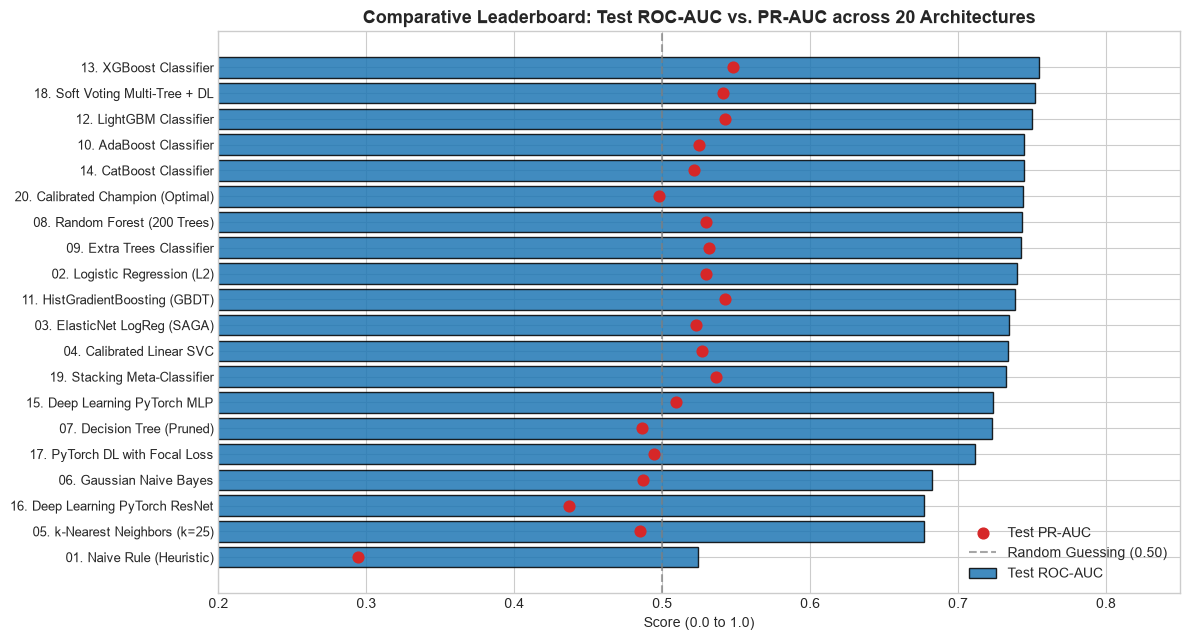

In [25]:
plt.figure(figsize=(12, 6.5))
sorted_df = lb_df.sort_values('test_auc', ascending=True)
y_pos = np.arange(len(sorted_df))

plt.barh(y_pos, sorted_df['test_auc'], color='#1f77b4', alpha=0.85, edgecolor='black', label='Test ROC-AUC')
plt.scatter(sorted_df['test_pr_auc'], y_pos, color='#d62728', s=60, zorder=3, label='Test PR-AUC')

plt.yticks(y_pos, sorted_df['model'], fontsize=9)
plt.xlabel("Score (0.0 to 1.0)")
plt.title("Comparative Leaderboard: Test ROC-AUC vs. PR-AUC across 20 Architectures", fontsize=13, fontweight='bold')
plt.xlim(0.2, 0.85)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guessing (0.50)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Visualization 2: ROC and Precision-Recall Curves for Representative Models
Comparing Naive Rule, Logistic Regression, Random Forest, PyTorch MLP, XGBoost, and the Champion Model.


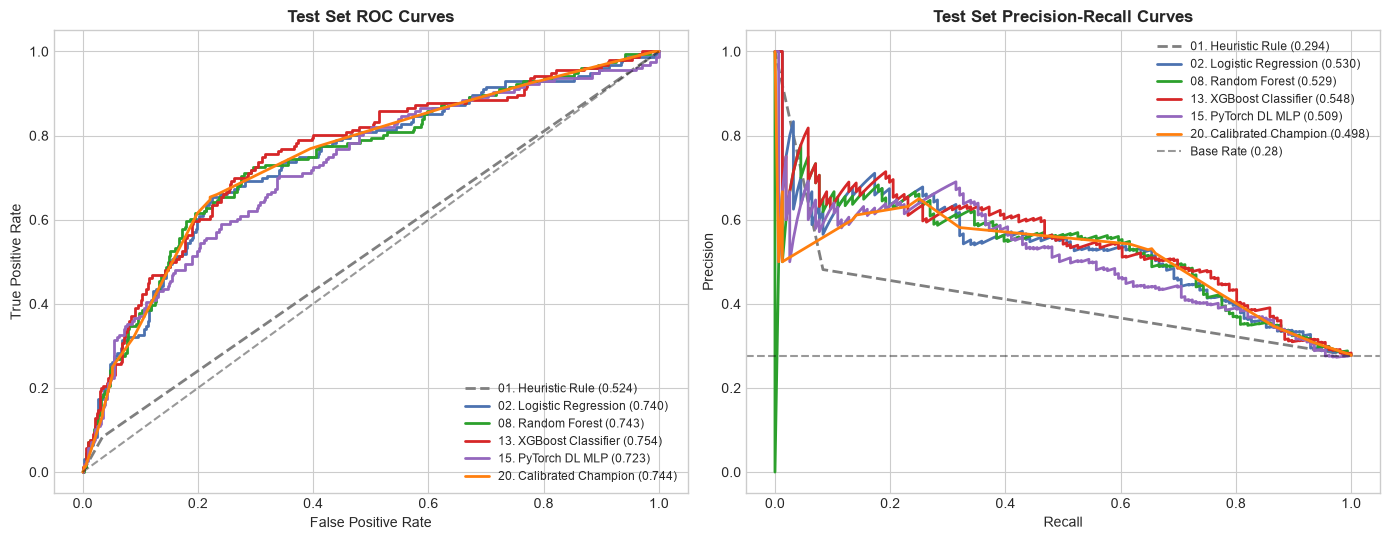

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

curve_models = [
    ("01. Heuristic Rule", t_pred, '#7f7f7f', '--'),
    ("02. Logistic Regression", m2_te, '#4c72b0', '-'),
    ("08. Random Forest", m8_te, '#2ca02c', '-'),
    ("13. XGBoost Classifier", m13_te, '#d62728', '-'),
    ("15. PyTorch DL MLP", m15_te, '#9467bd', '-'),
    ("20. Calibrated Champion", m20_te, '#ff7f0e', '-'),
]

# ROC Curves
for name, probs, col, ls in curve_models:
    fpr, tpr, _ = roc_curve(y_te, probs)
    score = roc_auc_score(y_te, probs)
    ax1.plot(fpr, tpr, color=col, linestyle=ls, lw=2, label=f"{name} ({score:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_title("Test Set ROC Curves", fontsize=12, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc='lower right', fontsize=8.5)

# PR Curves
for name, probs, col, ls in curve_models:
    p, r, _ = precision_recall_curve(y_te, probs)
    score = average_precision_score(y_te, probs)
    ax2.plot(r, p, color=col, linestyle=ls, lw=2, label=f"{name} ({score:.3f})")

ax2.axhline(y=y_te.mean(), color='k', linestyle='--', alpha=0.4, label=f"Base Rate ({y_te.mean():.2f})")
ax2.set_title("Test Set Precision-Recall Curves", fontsize=12, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()


### Visualization 3: Reliability Diagrams (Probability Calibration)
Comparing predicted probabilities against observed empirical keep rates across 10 deciles.


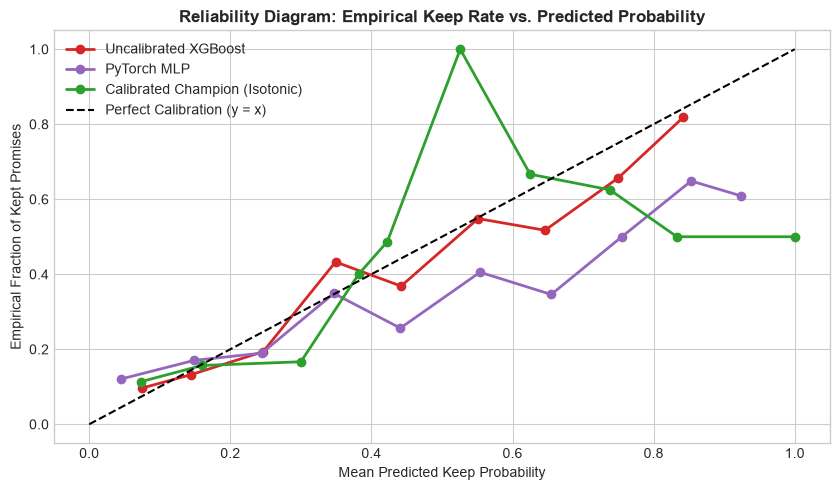

In [27]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8.5, 5))

for name, probs, col in [
    ("Uncalibrated XGBoost", m13_te, '#d62728'),
    ("PyTorch MLP", m15_te, '#9467bd'),
    ("Calibrated Champion (Isotonic)", m20_te, '#2ca02c'),
]:
    fop, mpv = calibration_curve(y_te, probs, n_bins=10)
    ax.plot(mpv, fop, marker='o', lw=2, color=col, label=name)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration (y = x)')
ax.set_title("Reliability Diagram: Empirical Keep Rate vs. Predicted Probability", fontsize=12, fontweight='bold')
ax.set_xlabel("Mean Predicted Keep Probability")
ax.set_ylabel("Empirical Fraction of Kept Promises")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Visualization 4: Operational Thresholding & Economic Value Curve
Assumes:
- **₹500** saved per correctly flagged broken PTP (preventing 7–14 days of lost contact window and escalation).
- **₹150** intervention cost per false alarm (sending digital nudges/verifying bank balance).


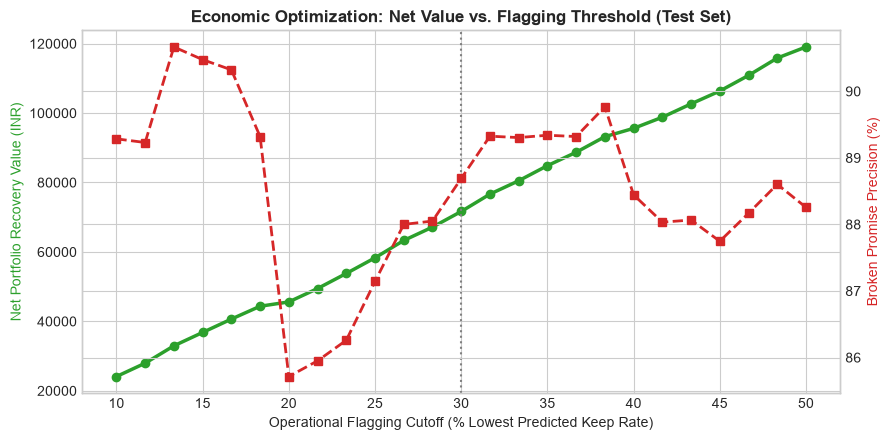

In [28]:
cutoffs = np.linspace(0.10, 0.50, 25)
savings_curve = []
prec_curve = []

for cut in cutoffs:
    n_flag = int(len(m13_te) * cut)
    flagged_idx = np.argsort(m13_te)[:n_flag]
    tp_broken = (y_te[flagged_idx] == 0).sum()
    fp_broken = (y_te[flagged_idx] == 1).sum()
    
    net_val = (tp_broken * 500) - (fp_broken * 150)
    savings_curve.append(net_val)
    prec_curve.append(tp_broken / max(n_flag, 1) * 100)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()

ax1.plot(cutoffs * 100, savings_curve, color='#2ca02c', lw=2.5, marker='o', label='Net Economic Value (INR)')
ax2.plot(cutoffs * 100, prec_curve, color='#d62728', lw=2, linestyle='--', marker='s', label='Broken Precision (%)')

ax1.set_xlabel("Operational Flagging Cutoff (% Lowest Predicted Keep Rate)")
ax1.set_ylabel("Net Portfolio Recovery Value (INR)", color='#2ca02c')
ax2.set_ylabel("Broken Promise Precision (%)", color='#d62728')
ax1.axvline(x=30, color='gray', linestyle=':', label='Chosen 30% Threshold')

plt.title("Economic Optimization: Net Value vs. Flagging Threshold (Test Set)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
